In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 19.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from konlpy.tag import Okt
import warnings
import platform
from matplotlib import font_manager, rcParams

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df00 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2000.csv")
df01 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2001.csv")
df02 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2002.csv")
df03 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2003.csv")
df04 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2004.csv")
df05 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2005.csv")
df06 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2006.csv")
df07 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2007.csv")
df08 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2008.csv")
df09 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_2009.csv")

In [ ]:
# 1. df20 ~ df29 concat (예: 2010년대)
dfs = [globals()[f'df{i:02}'] for i in range(0, 10)]
df_00s = pd.concat(dfs, ignore_index=True)

In [ ]:
# 2. 'lyric' 컬럼 전처리
lyrics = df_00s['lyric'].dropna().astype(str)
text = ' '.join(lyrics)
text = re.sub(r'[^가-힣a-zA-Z\s]', '', text)  # 영어 포함된 정제

In [ ]:
from konlpy.tag import Okt
import re

# 반복된 단어 제거 (예: '사랑 사랑', '나나 나나')
text = re.sub(r'\b(\w+)\s+\1\b', '', text)

# 3. 형태소 분석 + 불용어 제거 + 영어 단어 추출
okt = Okt()
stopwords = set([
    '는', '은', '이', '가', '을', '를', '에', '의', '도', '다', '고', '서', '한', '하',
    '해', '더', '것', '들', '지', '또', '때', '요', '듯', '좀', '듯이', '으로', '하며',
    '하고', '해서', '그', '저', '아', '야', '나', '니', '늘', '무슨', '왜', '어', '면'
    # '사랑 사랑' 제거는 위 정규식에서 처리했으므로 stopwords에서는 제거
])

# 3-1. 한글 명사 추출 및 불용어 제거
korean_tokens = okt.nouns(text)
korean_filtered = [word for word in korean_tokens if word not in stopwords and len(word) > 1]

# 3-2. 영어 단어 추출 (길이 2 이상 단어만)
english_tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text)

# 최종 결과 결합
all_tokens = korean_filtered + english_tokens

In [ ]:
# 4. 워드클라우드 준비
final_text = ' '.join(all_tokens)

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# matplotlib 설정
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager

# 드라이브에 있는 나눔스퀘어 폰트 경로 지정
font_path = '/content/drive/MyDrive/캡스톤EDA/NanumGothic.ttf'  # 본인의 경로에 맞게 수정

# 폰트 설정
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


폰트 이름: NanumGothic


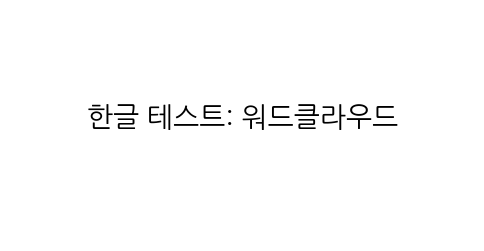

In [ ]:
from matplotlib import font_manager, rcParams
import matplotlib.pyplot as plt

# 구글 드라이브 폰트 경로
font_path = '/content/drive/MyDrive/캡스톤EDA/NanumGothic.ttf'

# FontProperties 생성
font_prop = font_manager.FontProperties(fname=font_path)

# 실제 시스템 인식 이름 확인
font_name = font_prop.get_name()
print(f"폰트 이름: {font_name}")  # 'NanumSquare_ac' 출력됨

# matplotlib 전체 설정
rcParams['font.family'] = font_name  # 그래도 설정해두기

# 간단한 테스트 그래프 (!!! fontproperties 지정하기 !!!)
plt.figure(figsize=(6, 3))
plt.text(0.5, 0.5, '한글 테스트: 워드클라우드', fontproperties=font_prop, fontsize=20, ha='center')
plt.axis('off')
plt.show()


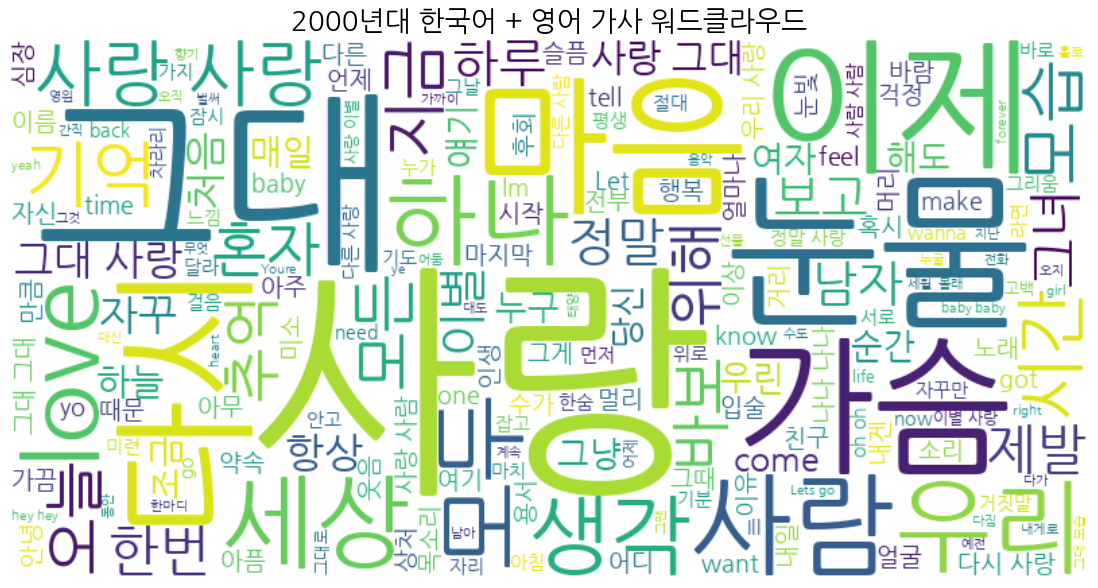

In [ ]:
# 시각화
from wordcloud import WordCloud # Import the WordCloud class

# Create a WordCloud object
wordcloud = WordCloud(font_path=font_path, width=800, height=400, background_color='white').generate(final_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("2000년대 한국어 + 영어 가사 워드클라우드", fontproperties=font_prop, fontsize=20)
plt.show()

In [ ]:
# 워드클라우드 결과에서 단어와 빈도수(정규화된 값)를 가져오기
words_freq = wordcloud.words_

# 빈도수가 높은 순서로 정렬
top_20_words = sorted(words_freq.items(), key=lambda x: x[1], reverse=True)[:20]

# 결과 출력
print("상위 20개 단어:")
for idx, (word, freq) in enumerate(top_20_words, 1):
    print(f"{idx}. {word}: {freq:.4f}")

상위 20개 단어:
1. 사랑: 1.0000
2. 그대: 0.5608
3. 눈물: 0.3822
4. 다시: 0.3102
5. 가슴: 0.3092
6. 마음: 0.3092
7. 이제: 0.3076
8. 사람: 0.2905
9. 세상: 0.2413
10. 우리: 0.2408
11. love: 0.2408
12. 하나: 0.2351
13. 모두: 0.2087
14. 생각: 0.2030
15. 사랑 사랑: 0.1968
16. 기억: 0.1942
17. 시간: 0.1875
18. 모습: 0.1688
19. 지금: 0.1543
20. 모든: 0.1507
